<a href="https://colab.research.google.com/github/podviginvadim/PA_LR/blob/main/PA_LR1_Podvigin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Предиктивная аналитика

# Лабораторная работа №1
## «Анализ и прогнозирование временных рядов на примере розничных продаж»

# Разведочный анализ данных (EDA)

In [296]:
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# Загрузка данных в датафрейм
df = pd.read_csv('retail_sales_mock_data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.index.freq = 'MS'  # месячная частота, начало месяца

print('Первые 5 строк:')
print(df.head())
print(f'\nПериод: {df.index[0].date()} — {df.index[-1].date()}')
print(f'Количество наблюдений: {len(df)}')
print(f'\nПропуски: {df.isnull().sum().sum()}')


Первые 5 строк:
            SalesAmount  Promotion  HolidayMonth
Date                                            
2020-01-01        12248          0             0
2020-02-01        13011          0             0
2020-03-01        12722          0             0
2020-04-01        14030          1             0
2020-05-01         7783          0             0

Период: 2020-01-01 — 2023-12-01
Количество наблюдений: 48

Пропуски: 0


Построим график продаж с обозначением акций и праздничных месяцев

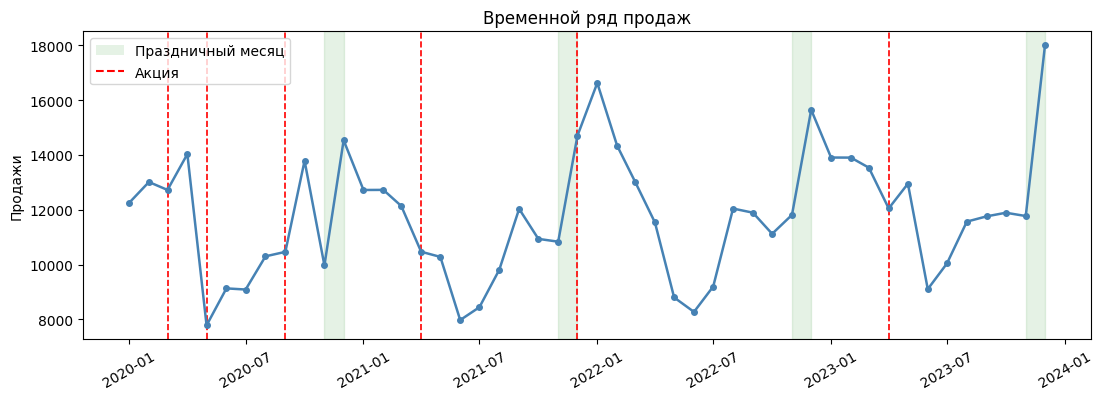

In [297]:
from matplotlib.patches import Patch
ts = df['SalesAmount']
fig, ax = plt.subplots(1, 1, figsize=(13, 4))

#Т.к. мы получаем данные на момент начала месяца, для обозначения месяцев, где были акции
# и праздничных месяцев вычитаем из индекса 1
for idx in df[df['HolidayMonth'] == 1].index:
    ax.axvspan(idx - pd.DateOffset(months=1), idx, alpha=0.1, color='g', label='Праздничный месяц')

for idx in df[df['Promotion'] == 1].index:
    ax.axvline(idx - pd.DateOffset(months=1), color='r', alpha=1, linestyle='--', linewidth=1.2)
handles = [
    Patch(facecolor='g', alpha=0.1, label='Праздничный месяц'),
    plt.Line2D([0], [0], color='r', linestyle='--', label='Акция')
]

ax.legend(handles=handles, loc='upper left')
ax.set_title('Временной ряд продаж')
ax.set_ylabel('Продажи')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.8, marker='o', markersize=4)

Временной ряд имеет помесячную периодичность с 2020 по 2023 год (48 наблюдений). График имеет восходящий тренд. В конце годов у графика видны пики, что говорит о сезонных коллебаниях. Можно сделать вывод, что ряд нестационарен. В месяца, в которые производились акции, чаще всего (Кроме одного случая) было увеличение продаж. В праздничные месяца видно сильное увеличение продаж.

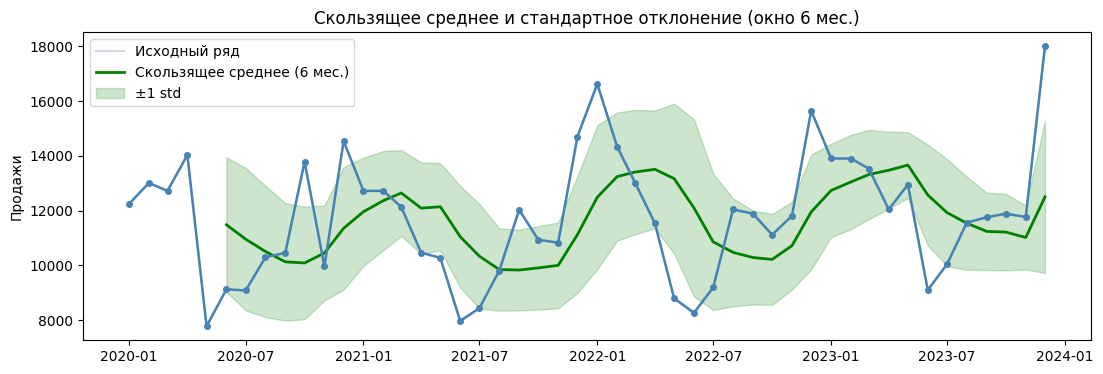

In [298]:
#Построим график скользящего среднего и стандартного отклонения

fig, ax = plt.subplots(1, 1, figsize=(13, 4))
roll_mean = ts.rolling(window=6).mean()
roll_std  = ts.rolling(window=6).std()
ax.plot(ts, color='lightsteelblue', alpha=0.6, label='Исходный ряд')
ax.plot(roll_mean, color='g', linewidth=2, label='Скользящее среднее (6 мес.)')
# fill_between закрашивает область ±1 стандартное отклонение вокруг среднего
ax.fill_between(ts.index, roll_mean - roll_std, roll_mean + roll_std,
                 alpha=0.2, color='g', label='±1 std')
ax.set_title('Скользящее среднее и стандартное отклонение (окно 6 мес.)')
ax.set_ylabel('Продажи')
ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.8, marker='o', markersize=4)
ax.legend()

Скользящее среднее показывает слабый восходящий тренд

ADF Statistic (SalesAmount): -4.51418
p-value: 0.00019
Ряд стационарен


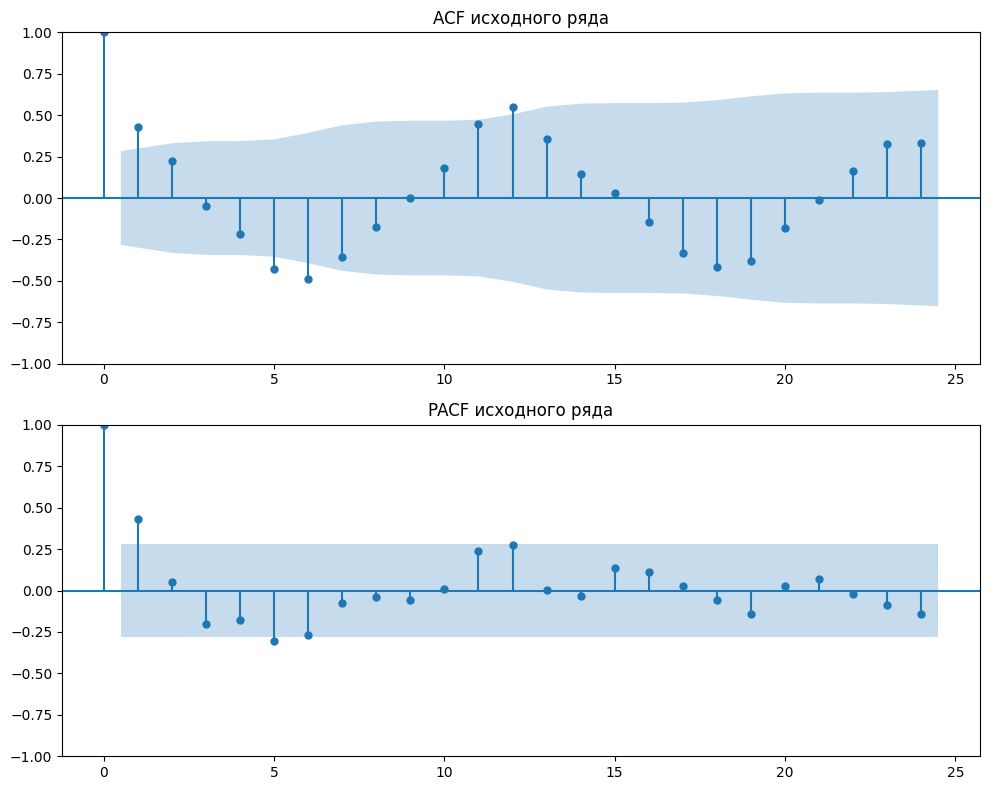

In [299]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ADF-тест на стационарность
result = adfuller(ts)
print(f'ADF Statistic (SalesAmount): {result[0]:.5f}')
print(f'p-value: {result[1]:.5f}')
if result[1] > 0.05:
    print("Ряд нестационарен")
else:
    print("Ряд стационарен")

# Графики ACF и PACF для ряда
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(ts, lags=24, ax=ax1)
ax1.set_title('ACF исходного ряда')
plot_pacf(ts, lags=24, ax=ax2)
ax2.set_title('PACF исходного ряда')
plt.tight_layout()
plt.show()

ACF демонстрирует значимые лаги на 0, 12, 24, это подтверждает годовую сезонность.
По ADF-тесту ряд стационарен (p < 0.05)

# Декомпозиция ряда

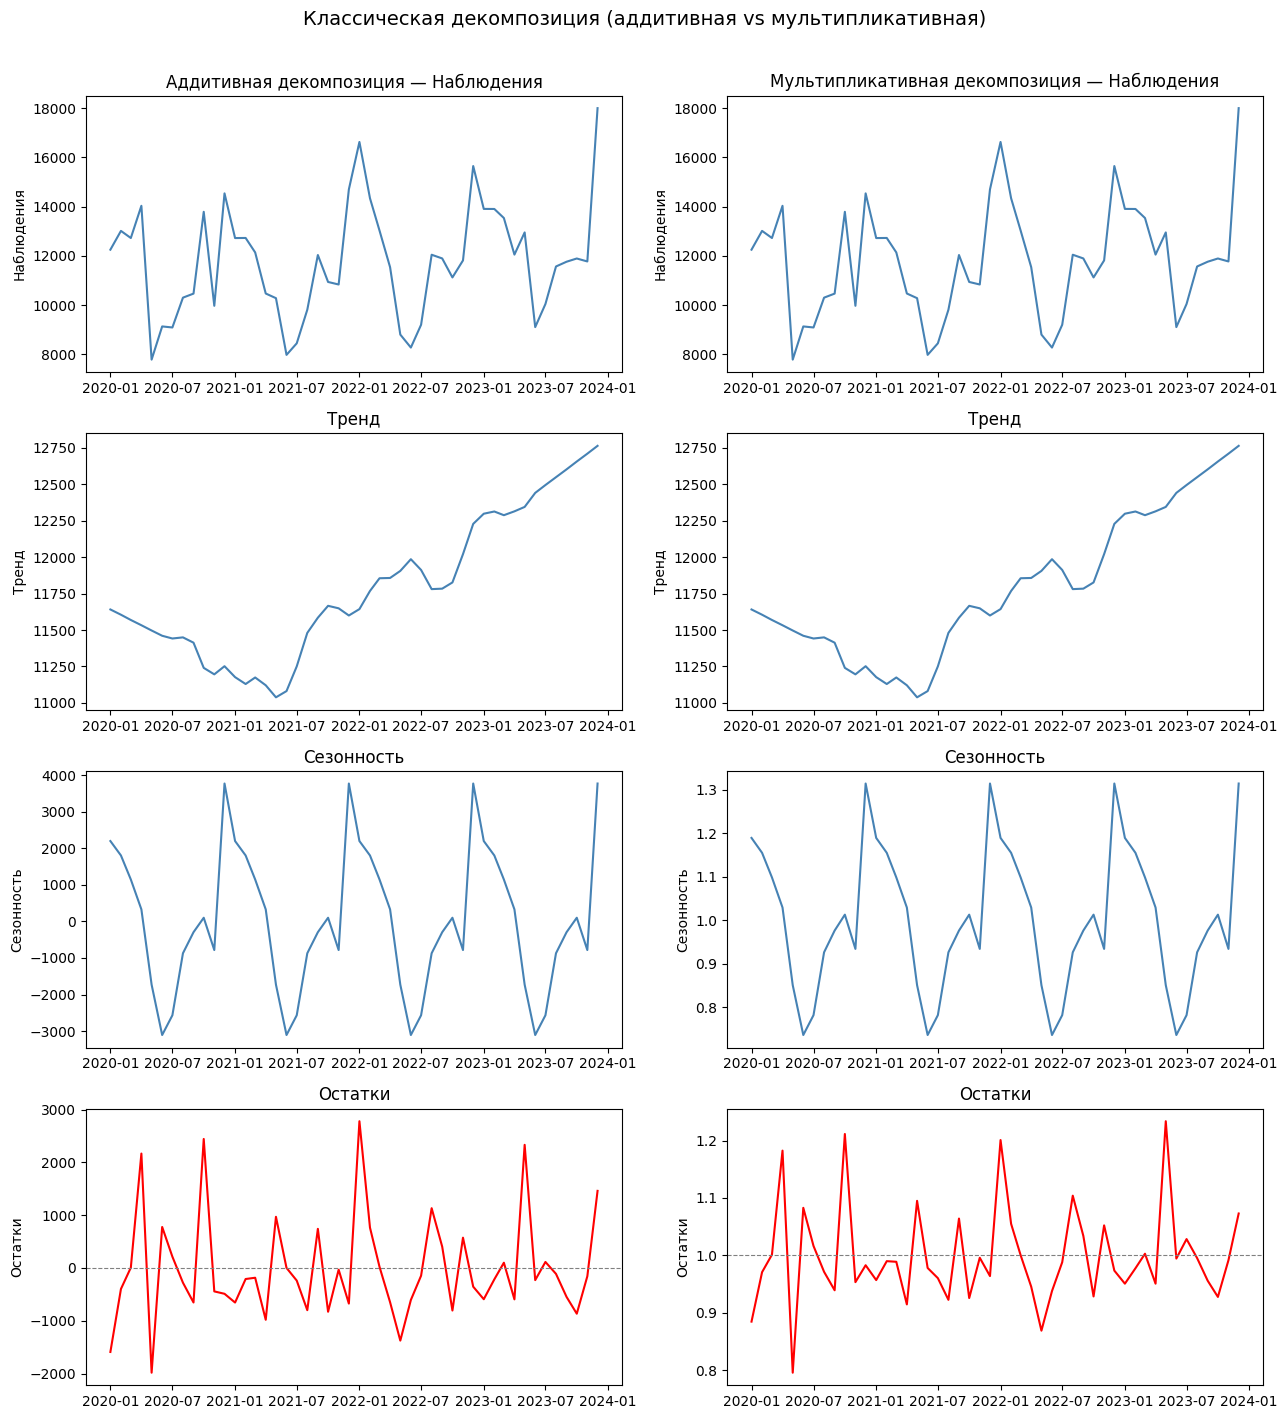

In [300]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
decomp_add  = seasonal_decompose(ts, model='additive',       period=12, extrapolate_trend='freq')
decomp_mult = seasonal_decompose(ts, model='multiplicative', period=12, extrapolate_trend='freq')
fig, axes = plt.subplots(4, 2, figsize=(13, 14))
components = ['observed', 'trend', 'seasonal', 'resid']
labels_ru  = ['Наблюдения', 'Тренд', 'Сезонность', 'Остатки']

for i, (comp, label) in enumerate(zip(components, labels_ru)):
    for j, (decomp, title) in enumerate([
            (decomp_add, 'Аддитивная'),
            (decomp_mult, 'Мультипликативная')]):
        ax = axes[i][j]
        data = getattr(decomp, comp)
        ax.plot(data, color='steelblue' if comp != 'resid' else 'r', linewidth=1.5)
        if comp == 'observed':
            ax.set_title(f'{title} декомпозиция — {label}')
        else:
            ax.set_title(label)
        ax.set_ylabel(label)
        if comp == 'resid':
            ax.axhline(0 if j == 0 else 1, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Классическая декомпозиция (аддитивная vs мультипликативная)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

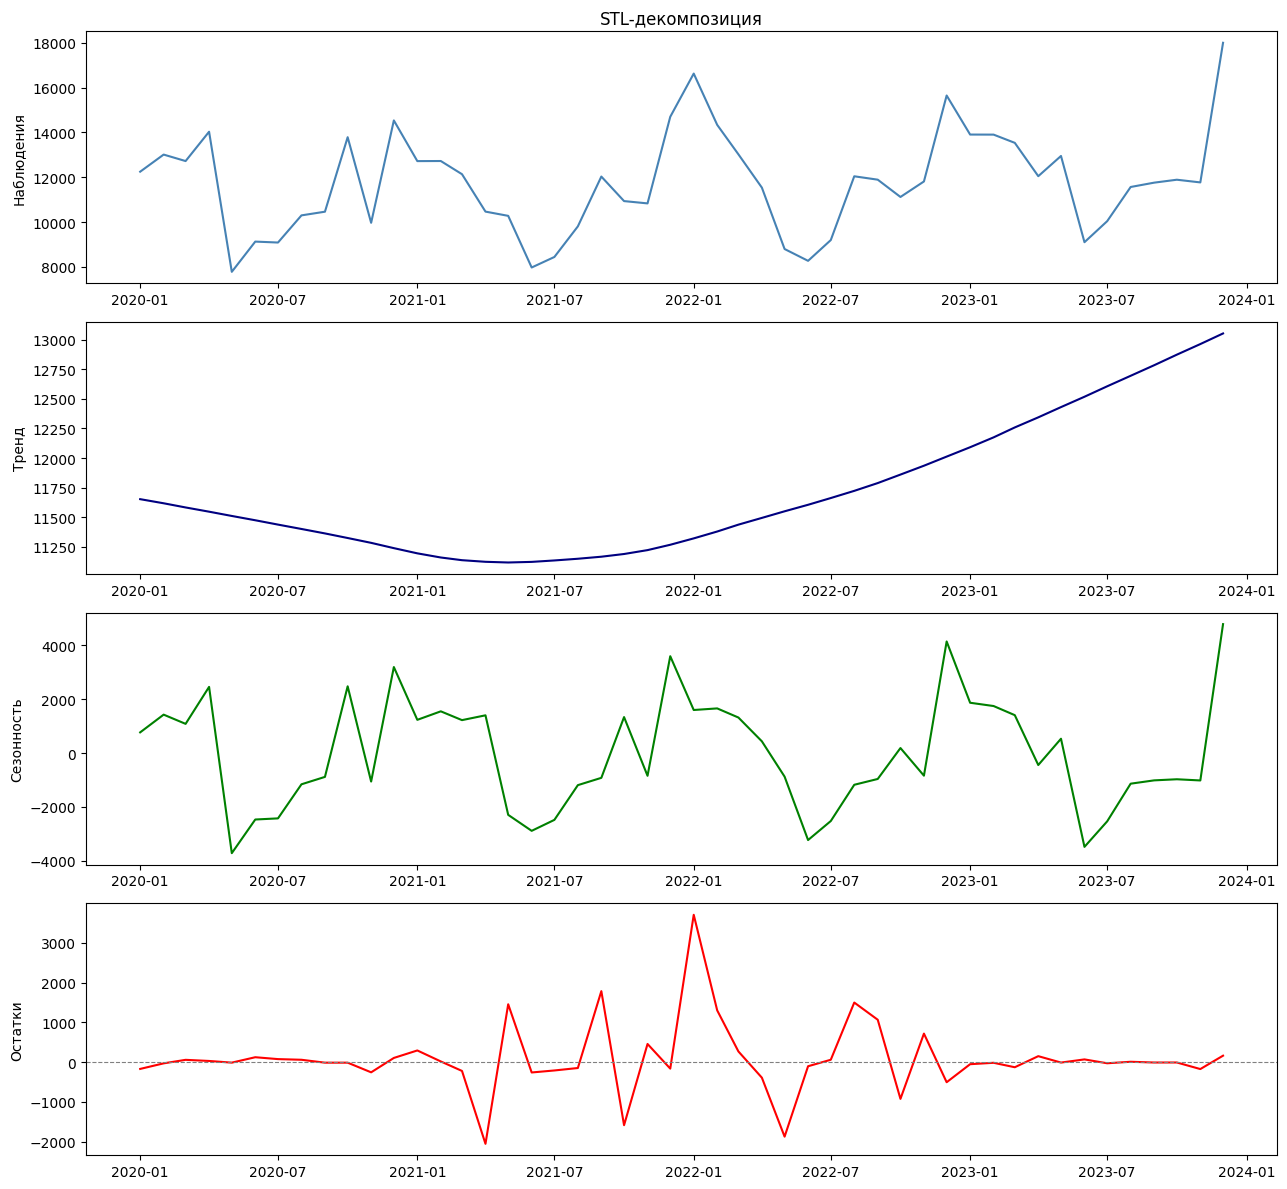

Сила тренда (STL):     0.257
Сила сезонности (STL): 0.839


In [301]:
import numpy as np
# STL-декомпозиция
stl = STL(ts, period=12, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 12))

for ax, data, label, color in zip(
        axes,
        [ts, stl_result.trend, stl_result.seasonal, stl_result.resid],
        ['Наблюдения', 'Тренд', 'Сезонность', 'Остатки'],
        ['steelblue', 'navy', 'g', 'r']):
    ax.plot(data, color=color, linewidth=1.5)
    ax.set_ylabel(label)
    if label == 'Остатки':
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

axes[0].set_title('STL-декомпозиция')
plt.tight_layout()
plt.savefig('decomp_stl.png', bbox_inches='tight')
plt.show()

Ft = max(0, 1 - np.var(stl_result.resid) / np.var(stl_result.trend + stl_result.resid))
Fs = max(0, 1 - np.var(stl_result.resid) / np.var(stl_result.seasonal + stl_result.resid))
print(f'Сила тренда (STL):     {Ft:.3f}')
print(f'Сила сезонности (STL): {Fs:.3f}')

Доминирующая частота: 0.083, следовательно период: 12.0 месяцев.


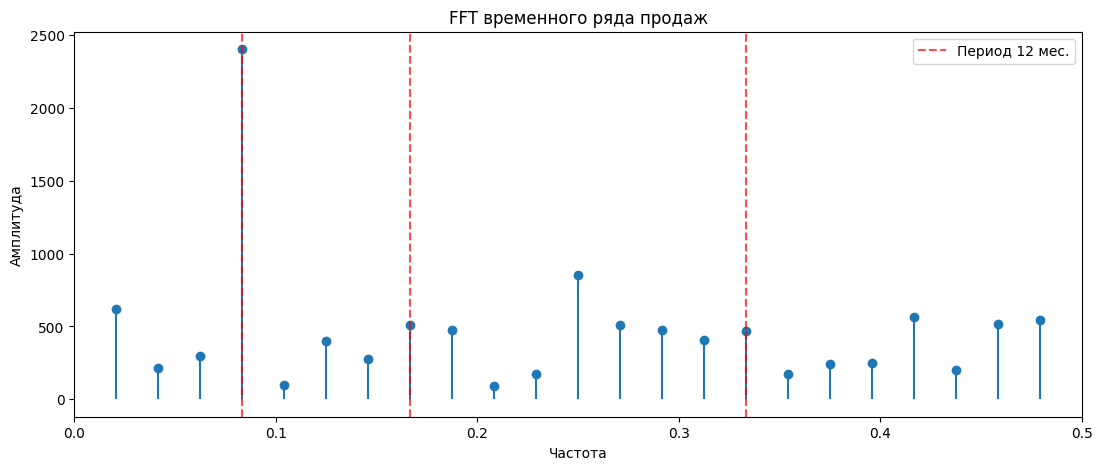

In [302]:
#Cпектральный анализ с применением быстрого преобразования Фурье
from scipy.fft import fft, fftfreq


# Вычисление FFT
n = len(ts)
sales_fft = fft(ts.values)
freq = fftfreq(n, d=1)  # d=1, так как период данных 1 месяц

# Берем только положительные частоты
positive_freq_idx = np.where(freq > 0)
freq_pos = freq[positive_freq_idx]
amplitude_pos = np.abs(sales_fft[positive_freq_idx]) / n * 2

plt.figure(figsize=(13, 5))
plt.stem(freq_pos, amplitude_pos, basefmt=" ")
plt.title('FFT временного ряда продаж')
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.xlim(0, 0.5)  # Ограничим до частоты Найквиста
peak_freq_idx = np.argmax(amplitude_pos[1:]) + 1 # Исключаем нулевую частоту
peak_freq = freq_pos[peak_freq_idx]
print(f"Доминирующая частота: {peak_freq:.3f}, следовательно период: {1 / peak_freq:.1f} месяцев.")
# Отметим на графице наиболее вероятные периоды (Год, полгода, месяц)
for period in [12, 6, 3]:
    f = 1/period
    if f < 0.5:
        plt.axvline(x=f, color='red', linestyle='--', alpha=0.7, label=f'Период {period} мес.' if period ==12 else "")
plt.legend()
plt.show()



[Text(0, 0, '2020'),
 Text(12, 0, '2021'),
 Text(24, 0, '2022'),
 Text(36, 0, '2023')]

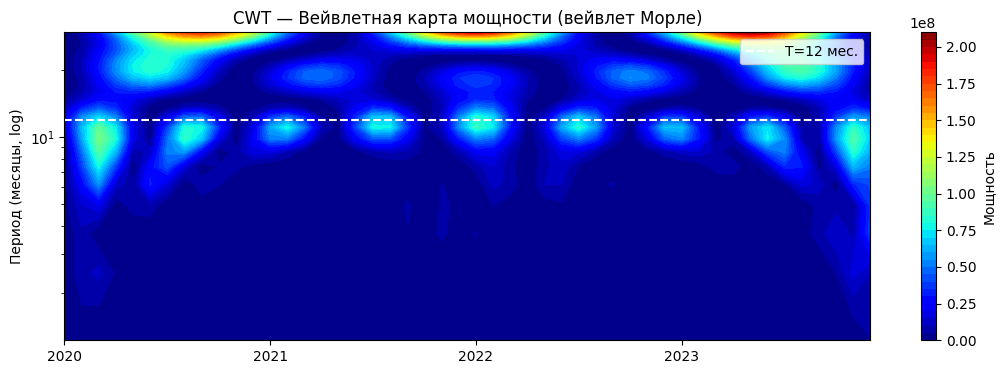

In [303]:
# Вейвлет-анализ
import pywt
scales = np.arange(1, 25)
wavelet = 'morl'  # Вейвлет Морле
coefs, freqs_w = pywt.cwt(ts.values, scales, wavelet, sampling_period=1)

# Мощность = квадрат модуля комплексных коэффициентов
power_w = np.abs(coefs)**2
fig, axes = plt.subplots(1, 1, figsize=(13, 4))
# Тепловая карта мощности
t_grid    = np.arange(len(ts))
periods_w = 1 / freqs_w
im = axes.contourf(t_grid, periods_w, power_w, levels=50, cmap='jet')
plt.colorbar(im, ax=axes, label='Мощность')  # Цветовая шкала
axes.set_yscale('log')
axes.set_ylabel('Период (месяцы, log)')
axes.set_title('CWT — Вейвлетная карта мощности (вейвлет Морле)')
# Линия на T=12 нужна чтобы проверить, есть ли годовая сезонность
axes.axhline(12, color='white', linestyle='--', linewidth=1.5, label='T=12 мес.')
axes.legend()
x_ticks = np.arange(0, len(ts), 12)  # Каждые 12 наблюдений = начало года
axes.set_xticks(x_ticks)
axes.set_xticklabels([str(ts.index[i].year) for i in x_ticks], fontsize=10)



Все методы подтверждают годичную сезонность.
аддитивная и мультипликативная декомпозиции практически не отличаются
STL декомпозиция показала восходящий тренд, у которого есть небольшой спад в 2021 году.
FFT дает четкую оценку сезонности в 12 месяцев.
# Построение прогнозных моделей

In [304]:
#Разделим обучающую выборку (для теста используем последние 12 месяцев)
train = ts[:-12]
test = ts[-12:]

print(f"Размер обучающей выборки: {len(train)}")
print(f"Размер тестовой выборки: {len(test)}")

Размер обучающей выборки: 36
Размер тестовой выборки: 12


In [305]:
# Модель ARIMA
#Т.к ряд нестационарен для подбора p и q найдем ACF/PACF дифференцированного ряда

result = adfuller(train.diff().dropna())
print(f'ADF(0)): {result[0]:.5f}')
print(f'p-value: {result[1]:.5f}')


ADF(0)): -4.59340
p-value: 0.00013


PACF после 2 лага нет сильных всплесков, следоватьельно p = 2

Так как ряд не стационарен и не линейн d = 2;

в ACF у нас 3 выброса, следовательно q = 3

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


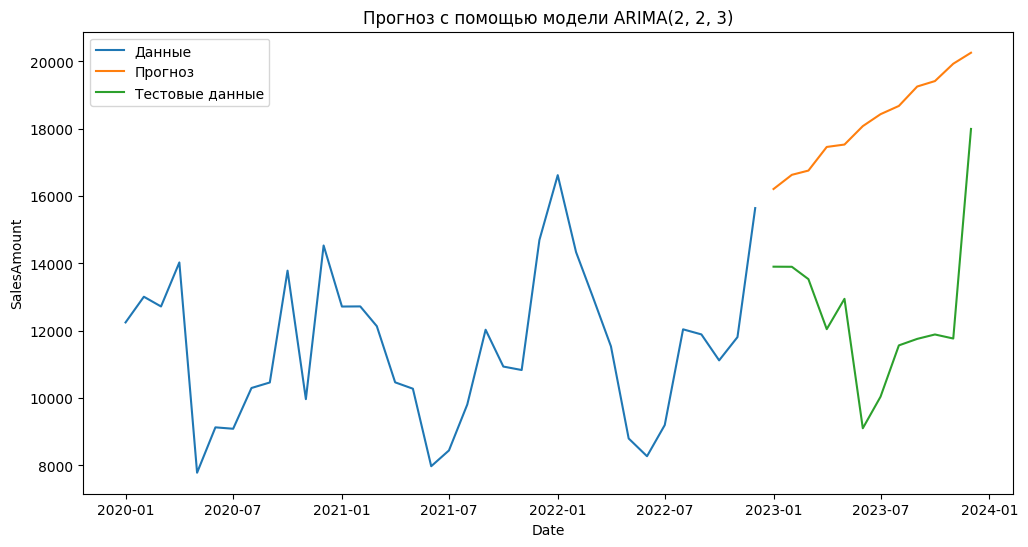

In [306]:
from statsmodels.tsa.arima.model import ARIMA
import seaborn as sns
model = ARIMA(train, order=(2, 2, 3)).fit()

# Прогноз на 12 месяца вперед
forecast_arima = model.predict(start=len(train), end=len(train)+11, typ='levels')
plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Данные')
sns.lineplot(data=forecast_arima, label='Прогноз')
sns.lineplot(data=test, label='Тестовые данные')
plt.title('Прогноз с помощью модели ARIMA(2, 2, 3)')
plt.show()



In [307]:
!pip install pmdarima

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=778.739, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=744.544, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=720.032, Time=0.10 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=0.66 sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=inf, Time=0.29 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=664.123, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=664.726, Time=0.08 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=666.636, Time=0.18 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.45 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.23 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=665.549, Time=0.13 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=667.495, Time=0.08 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.21 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=666.496, Ti

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


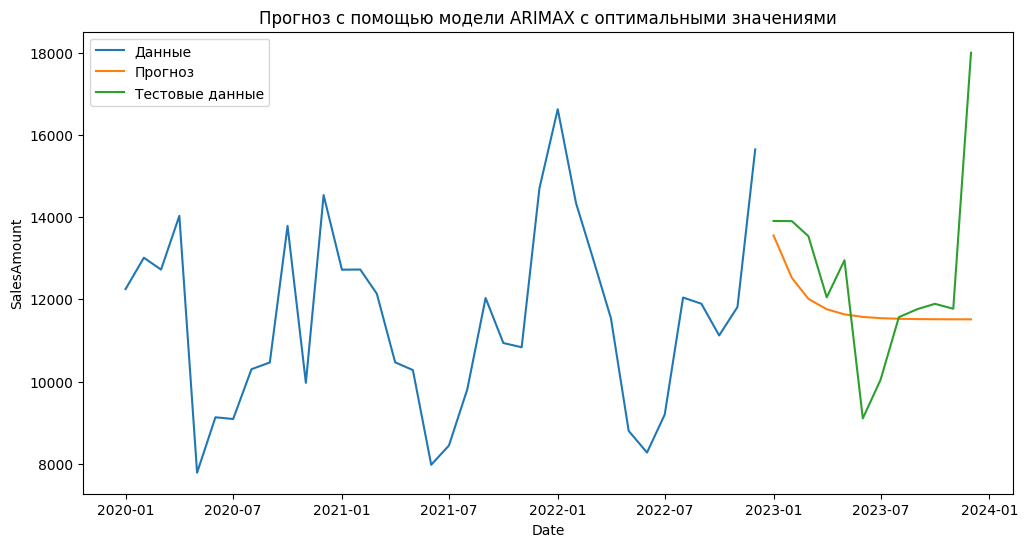

In [308]:
from pmdarima import auto_arima

# Попробуем подобрать параметры черезauto_arima
model = auto_arima(
    train,
    start_p=0, max_p=13,
    start_q=0, max_q=13,
    d=None,              #Автоматический подбор
    seasonal=False,
    trace=True,
    stepwise=False # перебор всех комбинаций
)

print(f"Оптимальный порядок: {model.order}")

model = ARIMA(train, order=model.order).fit()
# Прогноз на 12 месяца вперед
forecast_arima = model.predict(start=len(train), end=len(train)+11, typ='levels')
plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Данные')
sns.lineplot(data=forecast_arima, label='Прогноз')
sns.lineplot(data=test, label='Тестовые данные')
plt.title('Прогноз с помощью модели ARIMAХ c оптимальными значениями')
plt.show()

In [309]:
#Попробуем автоматически подобрать параметры для SARIMA
exog_train = df[['Promotion', 'HolidayMonth']][:-12]
exog_test = df[['Promotion', 'HolidayMonth']][-12:]
p = 1
d = 0
q = 0

P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
s = 12

best_aic_sarimax = np.inf
best_seasonal_order = None
best_model_sarimax = None

for P in P_values:
    for D in D_values:
        for Q in Q_values:
            try:
                model_test = SARIMAX(train,
                                exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, s),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                model_fit = model.fit(disp=False)
                if model_fit.aic < best_aic_sarimax:
                    best_aic_sarimax = model_fit.aic
                    best_seasonal_order = (P, D, Q, s)
                    best_model_sarimax = model_fit
            except:
                continue

print(f"Лучшая модель SARIMAX(1,0,0){best_seasonal_order} по AIC: {best_aic_sarimax:.2f}")

Лучшая модель SARIMAX(1,0,0)None по AIC: inf


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                                      SARIMAX Results                                       
Dep. Variable:                          SalesAmount   No. Observations:                   36
Model:             SARIMAX(1, 0, 0)x(1, 1, [1], 12)   Log Likelihood                -208.335
Date:                              Tue, 12 May 2026   AIC                            424.671
Time:                                      19:47:41   BIC                            429.383
Sample:                                  01-01-2020   HQIC                           425.921
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0212      0.131      0.162      0.871      -0.236       0.278
ar.S.L12      -0.98

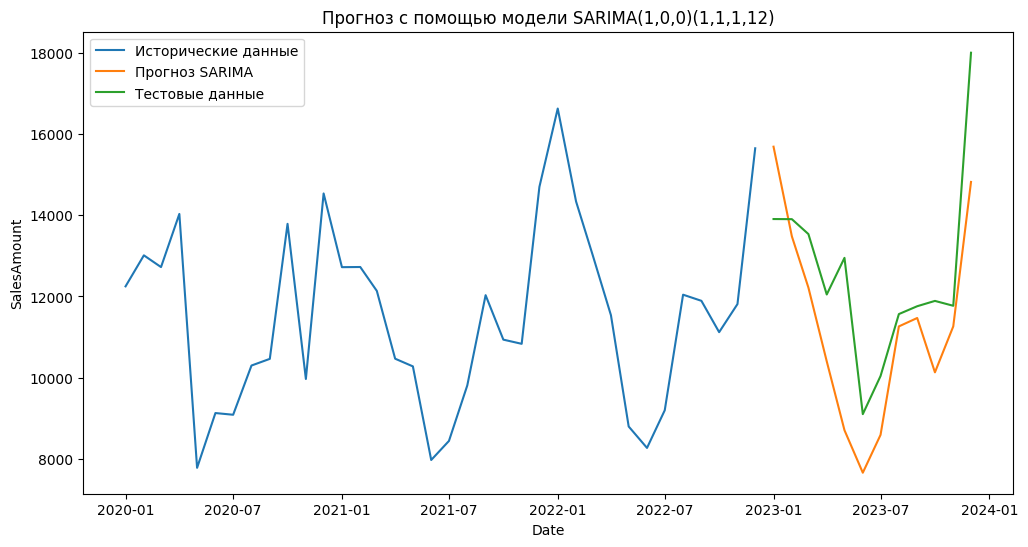

In [310]:
# Модель SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(train, order=(1, 0, 0), seasonal_order=(1, 1, 1, 12)).fit()
print(model_sarima.summary())

# Прогноз на 12 месяцев вперед
forecast_sarima = model_sarima.predict(start=len(train), end=len(train)+11, typ='levels')
plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Исторические данные')
sns.lineplot(data=forecast_sarima, label='Прогноз SARIMA')
sns.lineplot(data=test, label='Тестовые данные')
plt.title('Прогноз с помощью модели SARIMA(1,0,0)(1,1,1,12)')
plt.show()

Модель ARIMA не подходит для обучения модели т.к у нас ряд с определенной сезонностью.

Модель SARIMA учитывает сезонность, в связи с чем показывает более точный результат.

In [311]:
from sklearn.metrics import mean_squared_error, r2_score
mse_arima = mean_squared_error(test, forecast_arima)
r2_arima = r2_score(test, forecast_arima)
mse_sarima = mean_squared_error(test, forecast_sarima)
r2_sarima = r2_score(test, forecast_sarima)
print(f"MSE ARIMA, SARIMA: {mse_arima:.4f}, {mse_sarima:.4f}")
print(f"R²  ARIMA, SARIMA: {r2_arima:.4f}, {r2_sarima:.4f}")
print(f"AIC ARIMA, SARIMA: {model.aic:.2f}, {model_sarima.aic:.2f}")
print(f"BIC ARIMA, SARIMA: {model.bic:.2f}, {model_sarima.bic:.2f}")


MSE ARIMA, SARIMA: 4733414.5586, 3630935.5737
R²  ARIMA, SARIMA: -0.0235, 0.2149
AIC ARIMA, SARIMA: 653.07, 424.67
BIC ARIMA, SARIMA: 657.82, 429.38


In [312]:
#Тест Шапиро–Уилка
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
import statsmodels.api as sm

resid_a = model.resid
resid_s = model_sarima.resid

_, p_sw_a = stats.shapiro(resid_a.dropna())
_, p_sw_s = stats.shapiro(resid_s.dropna())
print(f'{"Тест Шапиро–Уилка (нормальность)"}   | p={p_sw_a:.4f}      | p={p_sw_s:.4f}')

#Тест Льюнга–Бокса
lb_a = acorr_ljungbox(resid_a.dropna(), lags=[12], return_df=True)
lb_s = acorr_ljungbox(resid_s.dropna(), lags=[12], return_df=True)
print(f'{"Тест Льюнга–Бокса (нет автокорр.)"} | p={lb_a["lb_pvalue"].values[0]:.4f}      | p={lb_s["lb_pvalue"].values[0]:.4f}')


#Тест Бройша–Пагана
fitted_a = model.fittedvalues.loc[resid_a.index]
exog_a   = sm.add_constant(fitted_a)
fitted_s = model.fittedvalues.loc[resid_s.index]
exog_s   = sm.add_constant(fitted_s)

bp_a = het_breuschpagan(resid_a.dropna(), exog_a)
bp_s = het_breuschpagan(resid_s.dropna(), exog_s)

print(f'{"Тест Бройша–Пагана (гомоскедаст.)"} | p={bp_a[1]:.4f}      | p={bp_s[1]:.4f}')


Тест Шапиро–Уилка (нормальность)   | p=0.2236      | p=0.0001
Тест Льюнга–Бокса (нет автокорр.) | p=0.0198      | p=0.0000
Тест Бройша–Пагана (гомоскедаст.) | p=0.3579      | p=0.7829


По параметрам MSE, R², AIC, BIC - SARIMA показывает лучший результат
```
Тест/Модель                       | ARIMA                           | SARIMA
Тест Шапиро–Уилка (нормальность)  | нормальность не отвергается     | остатки не нормальны
Тест Льюнга–Бокса (нет автокорр.) | автокорреляция                  | автокорреляция
Тест Бройша–Пагана (гомоскедаст.) | дисперсия стабильна             | дисперсия стабильна
```


